# Circuit gate analysis (device A1)

Loads `circuit_gate_analysis.csv` and reproduces the gate-count / wait-time / delay-histogram figure using `single_column.mplstyle`, matching the styling approach in `fig1_relaxation_main.ipynb`.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt

# Repo root (walk up to .git so this works from any CWD)
REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / '.git').exists():
    REPO_ROOT = REPO_ROOT.parent


In [ ]:
import importlib.util

plt.style.use(str(REPO_ROOT / "manuscript" / "figures_notebooks" / "single_column.mplstyle"))

_plot_py = REPO_ROOT / "manuscript" / "figures_notebooks" / "circuit_gate_analysis_plots.py"
_spec = importlib.util.spec_from_file_location(
    "circuit_gate_analysis_plots_live",
    _plot_py,
)
_cga = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_cga)

load_circuit_gate_dataframe = _cga.load_circuit_gate_dataframe
plot_device_a_panel = _cga.plot_device_a_panel



Bad key axes.grid.alpha in file /Users/krzywdaja/Documents/noisy-learning-advantage/figures_notebooks/single_column.mplstyle, line 30 ('axes.grid.alpha   : 0.35')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.4/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


In [ ]:
def plot_circuit_gate_analysis_manuscript(
    device: str = "A1",
    nq_extrap: float = 50,
    save_pdf: bool = True,
    figsize=(8, 3),
):
    """
    Two-panel figure: power-law gate/wait scaling (left) and delay-duration heatmap (right).
    Figure width ~2× single-column width; height similar to fig1_relaxation_main (4×2.8).
    """
    csv_path = REPO_ROOT / "manuscript" / "figures_notebooks" / "circuit_gate_analysis.csv"
    if not csv_path.is_file():
        raise FileNotFoundError(csv_path)

    df = load_circuit_gate_dataframe(csv_path)
    fig = plot_device_a_panel(
        df,
        device=device,
        nq_extrap=nq_extrap,
        show=False,
        figsize=figsize,
    )
    if save_pdf:
        out = REPO_ROOT / "manuscript" / "figures_manuscript" / "circuit_gate_analysis.pdf"
        out.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(str(out), bbox_inches="tight")
    plt.show()
    plt.close(fig)


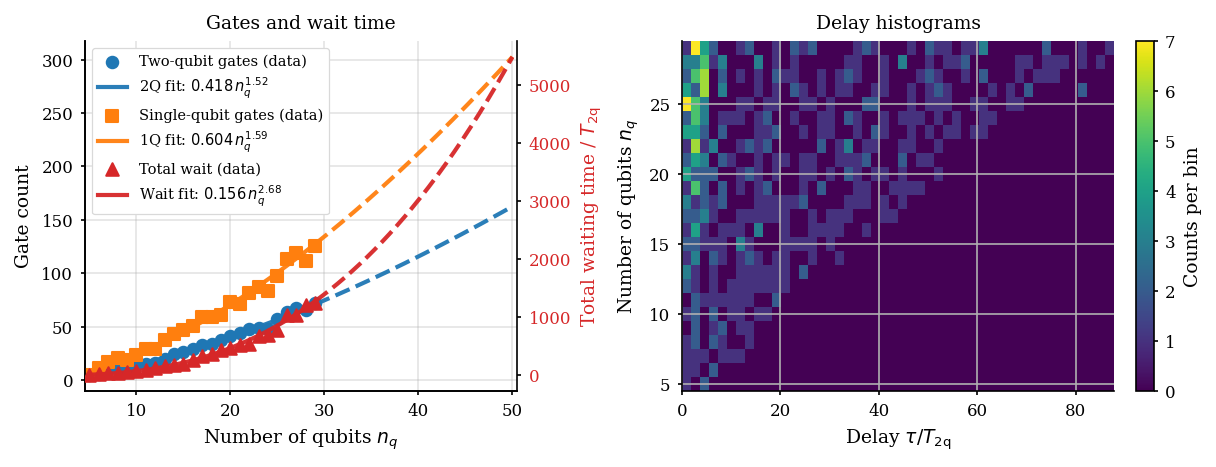

In [8]:
plot_circuit_gate_analysis_manuscript(save_pdf=True)